In [112]:
import torch
from torch import nn #nn contains building blocks for nueral networks
import matplotlib.pyplot as plt

## 1. Preparing data

In [113]:
# linear reggresion
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [114]:
len(X), len(y)

(50, 50)

### Splitting data into training and test data


In [115]:
train_split = int(0.8 * len(X)) #80/20 rule
X_train, y_train = X[:train_split], y[:train_split] #80
X_test, y_test = X[train_split:], y[train_split:] #20

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [116]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predicitons=None):
    plt.figure(figsize=(10,7))

    # training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")

    # testing data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing Data")

    # are there predicitons
    if predicitons is not None:
        plt.scatter(test_data, predicitons, c="r", s=4, label="Predicitons")

    plt.legend(prop={"size": 14});



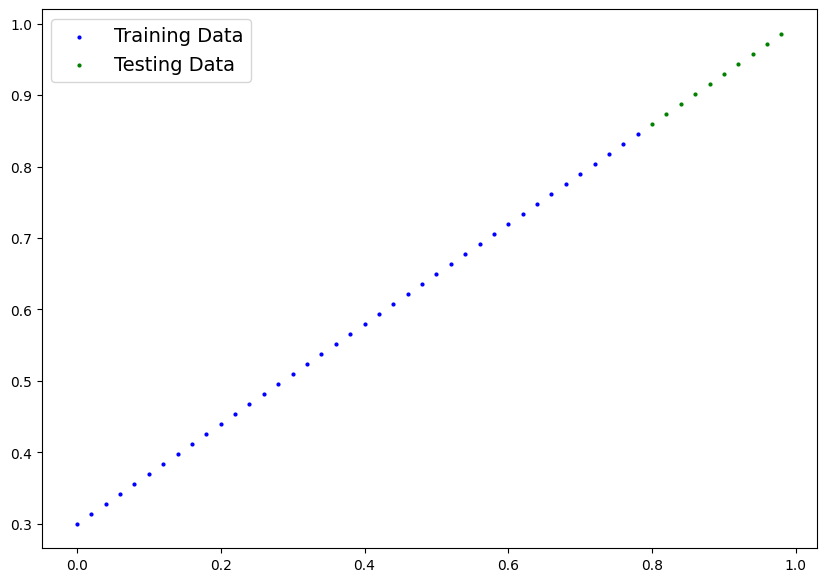

In [117]:
plot_predictions()

## 2. Build Model
* Gradient Descent
* Backpropagation

In [118]:
# linear regression model class
class LinearRergressionModel(nn.Module): # base class for all neural netwrok modules
    def __init__(self): 
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True, #defualt
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        
    #Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: #x is the input data 
        #(FORWARD method is the computation that is done at every cell)
        return self.weights * x + self.bias #linear regres formula

### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a nerual network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a pytorch layer from torch.nn will set these
* torch.nn.Module - The base class for all nerual modeules, if you subclass it, then overwrite forward()
* torch.optim - this is where the optimizers in pytorch live, they help with gradient descent
* def forward() - All nn.Module subcalsses requires to overwrite forward(), this method defines what happens in the forward computation

### Checking pytorch model

In [143]:
# random seed beacuse model uses randnumbers
torch.manual_seed(42)

# create an instance of the model (this is a sublcass of nn.Module)
model_0 = LinearRergressionModel()

# check out the params
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [144]:
# List named params
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [145]:
weight, bias

(0.7, 0.3)

### Making prediciton using `torch.inference_mode()`

See how well it predicts `y_test` based on `X_test`


In [146]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [147]:
# make predictions with model
with torch.inference_mode(): #disables grad = less memory (not needed during inference mode)
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [148]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

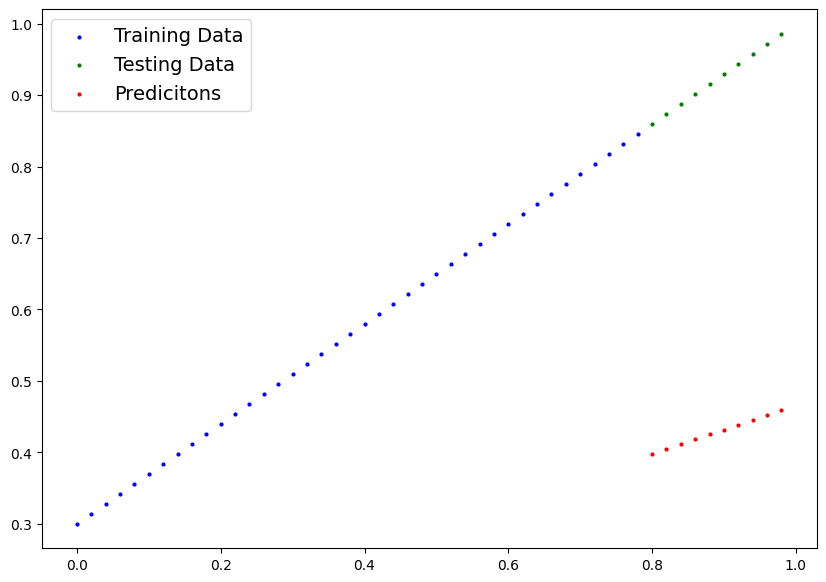

In [149]:
plot_predictions(predicitons=y_preds)

## 3. Train model
Need a way to now measure how poor or how wrong the model's predictions are, thats where loss functions come in

* Loss function may also be called cost function or criterion

Things we need to train

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias) to imporve the loss functiuon. 

And specifically for pytorch, we need: 
* A training loop
* A testing loop

In [150]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [151]:
# setup a loss function 
loss_fn = nn.L1Loss() #Mean Abs Error(mae)

# setup an optimizer (stochastic gradient descent (random numbers)) adjusts the params
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) #learning rate / alpha

### Building a training loop (and a testing loop) 
Things needed
1. loop through the data
2. forward pass (involves data moving through data's forward method) to make predictions on data - also called forward propagation
3. calcualte the loss(compare forward pass predictions)
4. optimizer zero grad
5. Loss backward- move backwards through the netwrok to calcualte the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
6. Optimizer step - use the optimizer to adjust our models parameters to try and imporve the loss (**gradient descent**)

In [ ]:
torch.manual_seed(42)
epochs = 200

#track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
for epoch in range(epochs): 
    # set the model to training mode
    model_0.train() # train mode sets all parameteters that require gradients to require gradients

    #1. Forward pass
    y_preds = model_0(X_train)

    #2. Calcualte the loss 
    loss = loss_fn(y_preds, y_train)
    print(f"Loss: {loss}")

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Perform backpropagation on the loss with rpespect to the parameters of the model
    loss.backward() #by defualt how the optimizer changes will acculamte through the loop so.. we have to zero them for the next iteration (np.zeros i think but it zeros it)

    #5. Step the optimizer (perform gradient descent)
    optimizer.step() 

    ### Testing
    model_0.eval() # turns off differernt settings and stuff not needed for eval
    with torch.inference_mode(): #disables gradient tracking
        #1. forward pass on TEST DATA
        test_pred = model_0(X_test) 

        #2. calcualte the loss on TEST DATA 
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Test: {loss} | Test loss: {test_loss}")

    

Loss: 0.31288138031959534
Epoch: 0 | Test: 0.31288138031959534 | Test loss: 0.48106518387794495
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Test: 0.1976713240146637 | Test loss: 0.3463551998138428
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Test: 0.08908725529909134 | Test loss: 0.21729660034179688
Loss: 0.08227583020925522
Loss: 0.07638873159885406
Loss: 0.07160007208585739
Loss: 0.06747635453939438
Loss: 0.06395438313484192
Loss: 0.06097004935145378
Loss: 0.05845819041132927
Loss: 0.05635259300470352
Loss: 0.0545857772231102
Loss: 0.05314852669

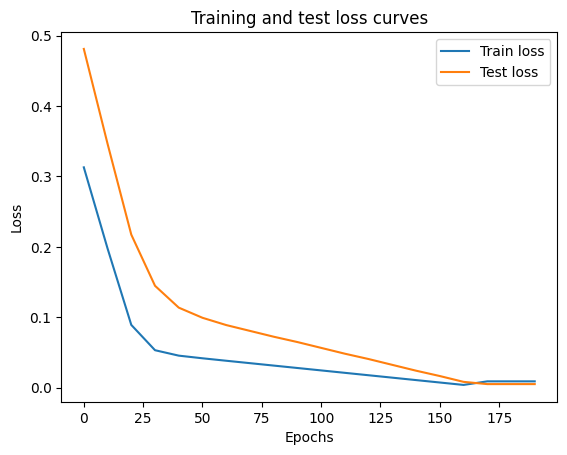

In [162]:
#plot loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [153]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [154]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [155]:
weight, bias

(0.7, 0.3)

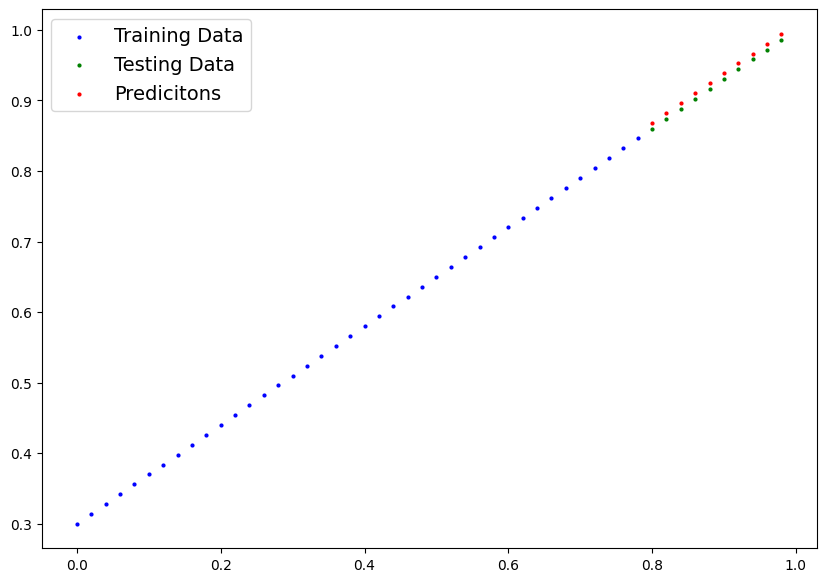

In [137]:
plot_predictions(predicitons=y_preds_new)

## Saving a model in pytorch 

Threee main methods

1. `torch.save()` - allows save via python pickle format
2. `torch.load()` - load saved pytorch obejct
3. `torch.nn.Module.load_state_dict()` - this allows to load a models saved state dictionary 

In [163]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Saving 
from pathlib import Path

#1. create models directiory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. create model save path
MODEL_NAME = "01_pytorch_model_0.pth" #pytorch file ext
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. save model (state.dict)
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_model_0.pth


## Loading a pytorch model

In [167]:
# load state dict
loaded_model_0 = LinearRergressionModel()

# Load the saved state_dict
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

C:\Users\fiore\AppData\Local\Temp\ipykernel_18836\4067715222.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)

<All keys matched successfully>

In [169]:
loaded_model_0.state_dict(), model_0.state_dict()

(OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))]),
 OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))]))

In [171]:
# Make predicitons
loaded_model_0.eval()
with torch.inference_mode(): 
    loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [177]:
loaded_model_0.eval()
with torch.inference_mode(): 
    y_preds = loaded_model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [178]:
# compare loaded model preds with orginal preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 4. Putting it all together


In [179]:
import torch
from torch import nn
import matplotlib.pyplot as plt

Create device-agnostic code.

This means if we got access to gpu our code will use it

In [181]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 4.1 Data